OUTLIER DETECTION USING Z-SCORE AND INTERQUARTILE RANGE

In [164]:
import mysql.connector
import configparser
import pandas as pd
from scipy.stats import iqr
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#Location of the ini file
config = configparser.ConfigParser()
config.read('C:\\Users\\svi02\\.spyder-py3\\erfpPROD.ini')

['C:\\Users\\svi02\\.spyder-py3\\erfpPROD.ini']

In [165]:
host=config['erfpPROD']['host']
user=config['erfpPROD']['user']
pwd=config['erfpPROD']['pwd']
database=config['erfpPROD']['database']

In [166]:
conn = mysql.connector.connect(
          host=host,
          user=user,
          passwd=pwd,
          database=database)
cursor = conn.cursor()

In [167]:
import_query_location = 'C:\\Users\\svi02\\Documents\\Green_score\\NORMALISED\\CSR_ENERGY_CERTIFIED.sql' 
import_query_open = open(import_query_location, 'r', encoding="utf8")
import_query_read = import_query_open.read()

In [168]:
sql_select_query = """SELECT 
        H.HOTEL_ID_VALUE AS HOTEL_ID
       ,H.HOTEL_NAME_NAME AS HOTEL_NAME   
       ,MEAS_ENERGY
       ,MEAS_ENERGY_AMT
       ,MEAS_ENERGY_UOM
       ,MEAS_ENERGY_PD 
       FROM GBTA_HOTEL_RFP.GBTA_ANSWERS_FOR_OFFER ANS
JOIN SOURCING.BI_ERFP_RFPENTITY RFP ON RFP.ID_VALUE = ANS.RFP_ID
JOIN SOURCING.BI_ERFP_HOTEL_FOR_RFPENTITY H ON RFP.ID_VALUE = H.OR_RFP_VALUE AND H.HOTEL_ID_VALUE = ANS.HOTEL_ID
WHERE 
      MEAS_ENERGY IS TRUE
   AND (MEAS_ENERGY_AMT IS NOT NULL OR MEAS_ENERGY_AMT <> 0)
   AND (MEAS_ENERGY_PD IS NOT NULL OR MEAS_ENERGY_PD <> 0) 
   AND MEAS_ENERGY_UOM LIKE 'BTU per Square Foot'"""

cursor.execute(import_query_read)

QUERY = cursor.fetchall()
print('Total Row(s):', cursor.rowcount)

# Importing data into a DataFrame
import pandas as pd
erfp_df = pd.DataFrame()
a=[]
for row in QUERY:
        a.append(row)

erfp_df = pd.DataFrame(a)
df_col_names =  [i[0] for i in cursor.description]
erfp_df.columns = df_col_names

Total Row(s): 1888


In [169]:
erfp_df.head()

,HOTEL_ID,MEAS_ENERGY,MEAS_ENERGY_AMT,MEAS_ENERGY_UOM_NORMALISED,MEAS_ENERGY_AMT_BTU,MEAS_ENERGY_PD,MAX_LATEST_DATE
0,NaN,1,1057.50,MEGA_JOULE,1002319.65000,12,NaT
1,490.0,1,197.60,BTU_PER_SQUARE_FOOT,197.60000,6,2019-09-06 07:03:30
2,545.0,1,123.21,BTU_PER_SQUARE_FOOT,123.21000,12,2019-09-05 15:59:51
3,579.0,1,481.00,BTU_PER_SQUARE_FOOT,481.00000,12,2019-09-05 17:56:38
4,598.0,1,320.07,BTU_PER_SQUARE_FOOT,320.07000,12,2019-09-05 14:27:57


In [170]:
erfp_df.MEAS_ENERGY_AMT_BTU = pd.to_numeric(erfp_df.MEAS_ENERGY_AMT_BTU)
erfp_df.dtypes

HOTEL_ID                             float64
MEAS_ENERGY                            int64
MEAS_ENERGY_AMT                       object
MEAS_ENERGY_UOM_NORMALISED            object
MEAS_ENERGY_AMT_BTU                  float64
MEAS_ENERGY_PD                         int64
MAX_LATEST_DATE               datetime64[ns]
dtype: object

In [171]:
energy_summary = pd.DataFrame({'MIN': erfp_df.MEAS_ENERGY_AMT_BTU.min(), 
                               'MAX': erfp_df.MEAS_ENERGY_AMT_BTU.max(), 
                               'AVG': erfp_df.MEAS_ENERGY_AMT_BTU.mean(), 
                               'MEDIAN': erfp_df.MEAS_ENERGY_AMT_BTU.median(), 
                               'MAD': erfp_df.MEAS_ENERGY_AMT_BTU.mad()}, index=[0])
energy_summary

,MIN,MAX,AVG,MEDIAN,MAD
0,0.07,448892291.1,304869.677,93.095,576540.120732


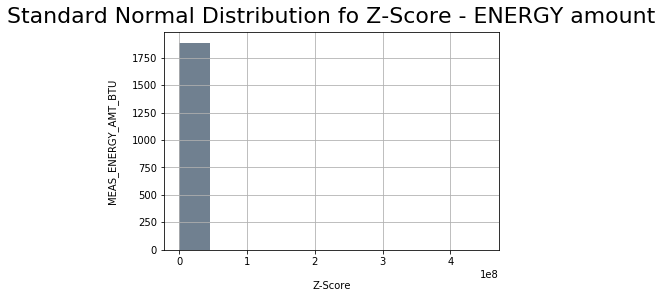

In [172]:
#MEAS_ENERGY_AMT = erfp_df.MEAS_ENERGY_AMT.to_numpy()
i = 'MEAS_ENERGY_AMT_BTU'
erfp_df[i].hist(color='slategray', bins= 10)
plt.title("Standard Normal Distribution fo Z-Score - ENERGY amount", y=1.015, fontsize=22)
plt.xlabel("Z-Score", labelpad=14)
plt.ylabel(i, labelpad=14);


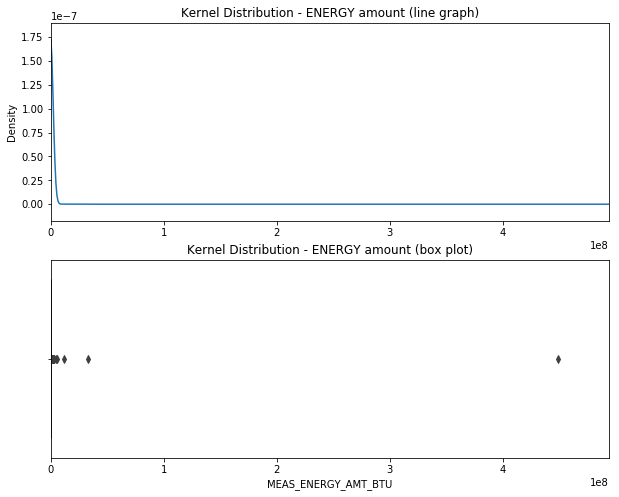

In [173]:
# Visualising to FIND the outliers

i = 'MEAS_ENERGY_AMT_BTU'
 
plt.figure(figsize=(10,8))
plt.subplot(211)
plt.xlim(erfp_df[i].min()*1.5, erfp_df[i].max()*1.1)
plt.title("Kernel Distribution - ENERGY amount (line graph)") 
ax = erfp_df[i].plot(kind='kde').margins(0.1)
 
plt.subplot(212)
plt.xlim(erfp_df[i].min()*1.5, erfp_df[i].max()*1.1)
plt.title("Kernel Distribution - ENERGY amount (box plot)") 
sns.boxplot(x=erfp_df[i])

In [174]:
# Remove any zeros (otherwise we get (-inf)
erfp_df.loc[erfp_df.MEAS_ENERGY_AMT_BTU == 0, 'MEAS_ENERGY_AMT_BTU'] = np.nan
erfp_df.loc[erfp_df.MEAS_ENERGY_AMT_BTU == 9999, 'MEAS_ENERGY_AMT_BTU'] = np.nan
erfp_df.loc[erfp_df.MEAS_ENERGY_AMT_BTU == 9999.99, 'MEAS_ENERGY_AMT_BTU'] = np.nan
 
# Drop NA
erfp_df.dropna(inplace=True)

erfp_df.shape

(1885, 7)

Text(0.5,1,'Kernel Distribution of Log transfomed values - ENERGY amount (box graph)')

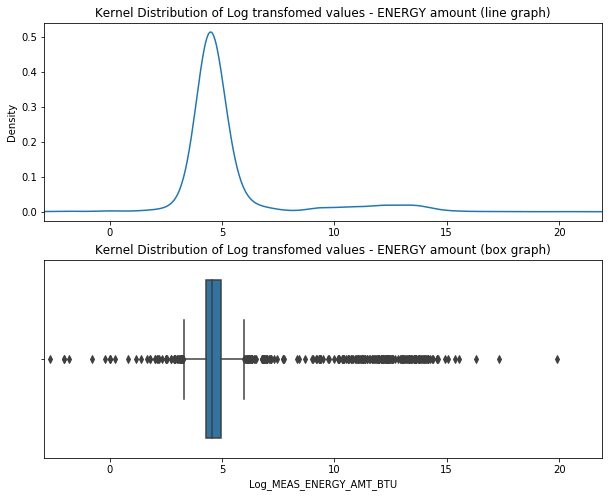

In [175]:
# Visualising Log Transform
erfp_df['Log_' + i] = np.log(erfp_df[i])

i = 'Log_MEAS_ENERGY_AMT_BTU'
 
plt.figure(figsize=(10,8))
plt.subplot(211)
plt.xlim(erfp_df[i].min()*1.1, erfp_df[i].max()*1.1)
plt.title("Kernel Distribution of Log transfomed values - ENERGY amount (line graph)") 

ax = erfp_df[i].plot(kind='kde')
 
plt.subplot(212)
plt.xlim(erfp_df[i].min()*1.1, erfp_df[i].max()*1.1)
sns.boxplot(x=erfp_df[i])
plt.title("Kernel Distribution of Log transfomed values - ENERGY amount (box graph)")

In [176]:
# OUTLIER DETECTION USING Z -SCORE
i = 'MEAS_ENERGY_AMT_BTU'
_mean = erfp_df[i].mean()
_std = erfp_df[i].std()

erfp_df[i + '_Zscore'] = (erfp_df[i] - _mean)/(_std)
erfp_df[i + '_Zscore_abs'] = erfp_df[i + '_Zscore'].apply(np.abs)

Text(0,0.5,'MEAS_ENERGY_AMT_BTU')

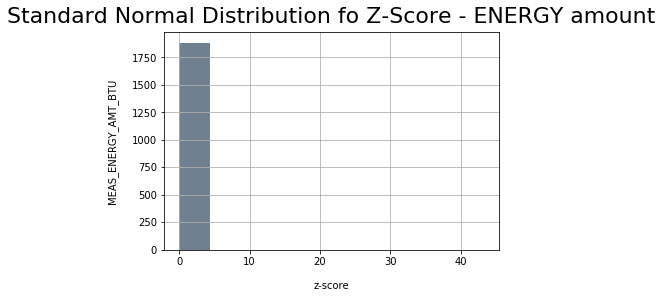

In [177]:
erfp_df[i + '_Zscore'].hist(color='slategray')
plt.title("Standard Normal Distribution fo Z-Score - ENERGY amount", y=1.015, fontsize=22)
plt.xlabel("z-score", labelpad=14)
plt.ylabel(i, labelpad=14)

In [178]:
erfp_df['MEAS_ENERGY_AMT_BTU_Zscore_abs'].min()

0.0005110864286273958

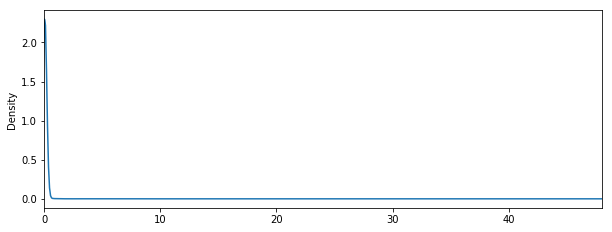

In [73]:
# erfp_df['MEAS_ENERGY_AMT_BTU_Zscore_abs']
# # Visualising Log Transform
# erfp_df['Log_' + i] = np.log(erfp_df[i])

i = 'MEAS_ENERGY_AMT_BTU_Zscore_abs'
 
plt.figure(figsize=(10,8))
plt.subplot(211)
plt.xlim(erfp_df[i].min()*1.1, erfp_df[i].max()*1.1)
 
ax = erfp_df[i].plot(kind='kde')

In [74]:
erfp_df.Log_MEAS_ENERGY_AMT_BTU.describe()

count    7250.000000
mean        7.866221
std         3.939619
min        -4.605170
25%         4.463635
50%         5.484667
75%        11.399265
max        20.092382
Name: Log_MEAS_ENERGY_AMT_BTU, dtype: float64

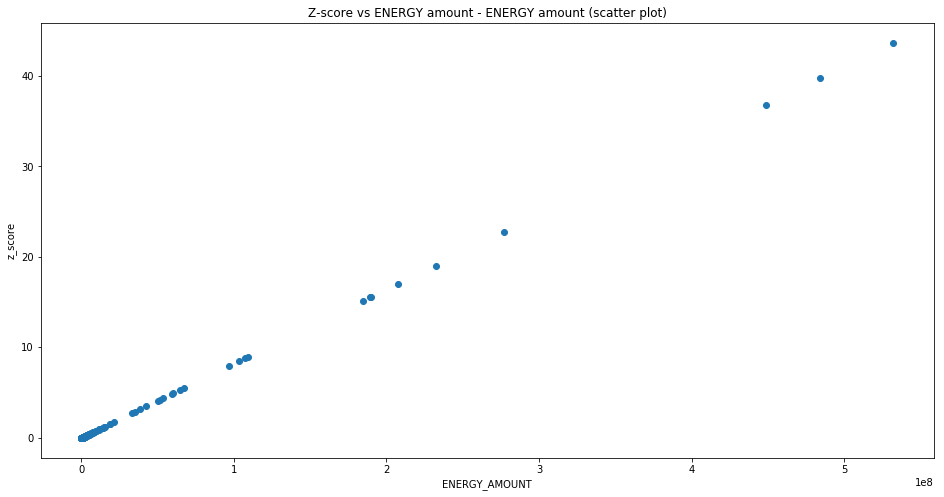

In [75]:
fig, ax = plt.subplots(figsize=(16,8))
ax.scatter(erfp_df['MEAS_ENERGY_AMT_BTU'], erfp_df['MEAS_ENERGY_AMT_BTU_Zscore'])
ax.set_xlabel('ENERGY_AMOUNT')
ax.set_ylabel('z_score')
plt.title("Z-score vs ENERGY amount - ENERGY amount (scatter plot)") 
plt.show()

In [189]:
# IQR
q1, q3= np.percentile(erfp_df.Log_MEAS_ENERGY_AMT_BTU,[25,75])
iqr = q3 - q1
iqr, q1, q3, 1.5*iqr

(0.6710614158477091, 4.287578583130166, 4.958639998977875, 1.0065921237715636)

In [190]:
LB = q1 -(1.5 * iqr) 
UB = q3 +(1.5 * iqr) 
LB,UB

(3.2809864593586027, 5.965232122749439)

In [191]:
erfp_df[(erfp_df['Log_MEAS_ENERGY_AMT_BTU'] > UB)|(erfp_df['Log_MEAS_ENERGY_AMT_BTU'] < LB)].count()

HOTEL_ID                          272
MEAS_ENERGY                       272
MEAS_ENERGY_AMT                   272
MEAS_ENERGY_UOM_NORMALISED        272
MEAS_ENERGY_AMT_BTU               272
MEAS_ENERGY_PD                    272
MAX_LATEST_DATE                   272
Log_MEAS_ENERGY_AMT_BTU           272
MEAS_ENERGY_AMT_BTU_Zscore        272
MEAS_ENERGY_AMT_BTU_Zscore_abs    272
Outlier                           272
dtype: int64

Text(0.5,1,'IQR Outlier detection - ENERGY amount (box plot)')

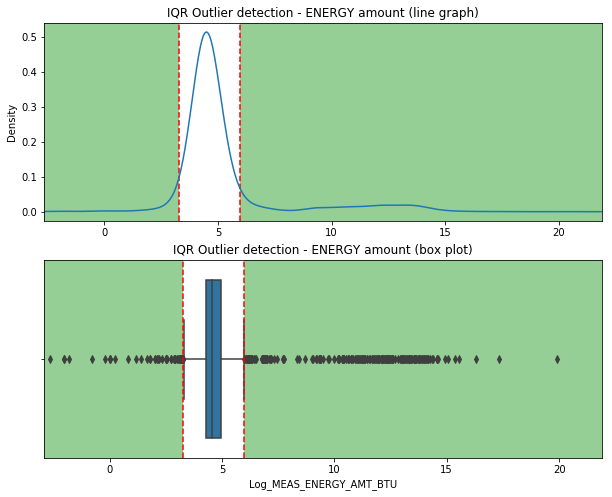

In [192]:
i = 'Log_MEAS_ENERGY_AMT_BTU'

plt.figure(figsize=(10,8))
plt.subplot(211)
plt.xlim(erfp_df[i].min(), erfp_df[i].max()*1.1)
plt.axvline(x=LB, color='r', ls = '--')
plt.axvspan(xmin=LB, xmax=erfp_df[i].min(), facecolor='#2ca02c', alpha=0.5)
plt.axvline(x=UB, color='r', ls = '--')
plt.axvspan(xmin=UB, xmax=erfp_df[i].max()*1.1, facecolor='#2ca02c', alpha=0.5)
plt.title("IQR Outlier detection - ENERGY amount (line graph)") 

ax = erfp_df[i].plot(kind='kde')

plt.subplot(212)
plt.xlim(erfp_df[i].min()*1.1, erfp_df[i].max()*1.1)
sns.boxplot(x=erfp_df[i])
plt.axvline(x=LB, color='r', ls = '--')
plt.axvspan(xmin=LB, xmax=erfp_df[i].min()*1.1, facecolor='#2ca02c', alpha=0.5)
plt.axvline(x=UB, color='r', ls = '--')
plt.axvspan(xmin=UB, xmax=erfp_df[i].max()*1.1, facecolor='#2ca02c', alpha=0.5)
plt.title("IQR Outlier detection - ENERGY amount (box plot)") 

In [183]:
i = 'Log_MEAS_ENERGY_AMT_BTU'

erfp_df['Outlier'] = 0
 
erfp_df.loc[erfp_df[i] < LB, 'Outlier'] = 1
erfp_df.loc[erfp_df[i] > UB, 'Outlier'] = 1

In [184]:
erfp_df.MEAS_ENERGY_AMT_BTU.mad()

576721.6319603404

In [185]:
type(erfp_df.MEAS_ENERGY_AMT)

pandas.core.series.Series

In [186]:
erfp_df.shape

(1885, 11)

In [187]:
erfp_df[erfp_df.Outlier != 1].MEAS_ENERGY_AMT_BTU.max()

278.21

In [162]:
erfp_df[erfp_df.Outlier == 1]

,HOTEL_ID,MEAS_ENERGY,MEAS_ENERGY_AMT,MEAS_ENERGY_UOM_NORMALISED,MEAS_ENERGY_AMT_BTU,MEAS_ENERGY_PD,MAX_LATEST_DATE,Log_MEAS_ENERGY_AMT_BTU,MEAS_ENERGY_AMT_BTU_Zscore,MEAS_ENERGY_AMT_BTU_Zscore_abs,Outlier
30,520,1,56509.00,MEGA_JOULE,5.356036e+07,1,2019-09-05 15:48:55,17.796320,4.342758,4.342758,1
274,7434,1,292537.00,MEGA_JOULE,2.772724e+08,1,2019-09-04 20:25:47,19.440511,22.730334,22.730334,1
616,25065,1,0.37,BTU_PER_SQUARE_FOOT,3.700000e-01,12,2019-09-05 15:48:55,-0.994252,-0.059531,0.059531,1
651,29501,1,37065.17,MEGA_JOULE,3.513111e+07,12,2019-09-05 14:27:57,17.374598,2.828002,2.828002,1
825,45985,1,0.07,BTU_PER_SQUARE_FOOT,7.000000e-02,12,2019-09-04 20:25:47,-2.659260,-0.059531,0.059531,1
1054,67467,1,40759.67,MEGA_JOULE,3.863283e+07,12,2019-09-03 09:44:31,17.469613,3.115819,3.115819,1
1110,70249,1,510770.00,MEGA_JOULE,4.841180e+08,12,2019-09-04 01:46:20,19.997839,39.731605,39.731605,1
1387,84140,1,0.01,BTU_PER_SQUARE_FOOT,1.000000e-02,12,2019-09-04 20:25:47,-4.605170,-0.059531,0.059531,1
1424,88197,1,113237.43,MEGA_JOULE,1.073287e+08,12,2019-09-04 20:25:47,18.491407,8.762142,8.762142,1
1955,108850,1,0.10,BTU_PER_SQUARE_FOOT,1.000000e-01,1,2019-05-31 17:53:32,-2.302585,-0.059531,0.059531,1


In [80]:
# OUTLIER
erfp_df[erfp_df.Outlier == 1].to_excel('C:\\Users\\svi02\\Documents\\Green_score\\ENERGY_outliers.xlsx', 
                sheet_name='ENERGY_outlier')

In [188]:
import datetime as d
file = "C:\\Users\\svi02\\Documents\\Green_score\\ENERGY_CERTIFIED.xlsx" 
with pd.ExcelWriter(file) as writer: 
    erfp_df[erfp_df.Outlier == 1].to_excel(writer, sheet_name='OUTLIER', header=True, encoding='utf-8', index=False, freeze_panes=(1,1))
    erfp_df[erfp_df.Outlier == 0].to_excel(writer, sheet_name='BENCHMARK', header=True, encoding='utf-8', index=False, freeze_panes=(1,1))